# LIBRARY

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

import keras
import tensorflow as tf
from keras import models, layers, optimizers, callbacks, regularizers, initializers
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score
import gzip 
import pickle 

# DATAFRAMES

In [24]:
with gzip.open("../1.DATASET/CMI_timeseries_dataset.pkl.gz", "rb") as f:
	 CMI_timeseries_dataset = pickle.load(f)

In [25]:
# Check how many subjects/time series
print(f"Number of time series: {len(CMI_timeseries_dataset)}")

Number of time series: 4437


## FIRST ANALYSES

### COLUMNS

In [26]:
df = CMI_timeseries_dataset[0].copy()

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   X                    200 non-null    float32
 1   Y                    200 non-null    float32
 2   Z                    200 non-null    float32
 3   enmo                 200 non-null    float32
 4   anglez               200 non-null    float32
 5   non-wear_flag        200 non-null    float32
 6   light                200 non-null    float32
 7   battery_voltage      200 non-null    float32
 8   weekday              200 non-null    float64
 9   quarter              200 non-null    float64
 10  relative_date_PCIAT  200 non-null    float32
 11  id                   200 non-null    int64  
 12  sii_binary           200 non-null    int64  
dtypes: float32(9), float64(2), int64(2)
memory usage: 13.4 KB


### CLASS BALANCE

In [28]:
# 1. Check class balance across all subjects
sii_distribution = [df['sii_binary'].iloc[0] for df in CMI_timeseries_dataset]
print(f"Class distribution: {sum(sii_distribution)} problematic, {len(sii_distribution)-sum(sii_distribution)} non-problematic")

Class distribution: 1480 problematic, 2957 non-problematic


### NULL VALUES

In [29]:
# Check if ANY nulls exist in the entire dataset
total_nulls = 0
for i, df in enumerate(CMI_timeseries_dataset):
    if df.isnull().any().any():
        total_nulls += df.isnull().sum().sum()
        print(f"DataFrame {i} has null values")

if total_nulls == 0:
    print("✅ No null values found in any DataFrame!")
else:
    print(f"❌ Found {total_nulls} total null values")

✅ No null values found in any DataFrame!


### UNIQUE VALUES

In [30]:
# Focus on columns that should have limited unique values
categorical_like = ['weekday', 'quarter', 'sii_binary', 'id', 'non-wear_flag']
continuous_like = ['X', 'Y', 'Z', 'enmo', 'anglez', 'light', 'battery_voltage', 'relative_date_PCIAT']

print("="*80)
print("CATEGORICAL/DISCRETE COLUMNS ANALYSIS")
print("="*80)

for col in categorical_like:
    all_values = set()
    for df in CMI_timeseries_dataset:
        all_values.update(df[col].unique())
    
    print(f"\n🔷 {col}:")
    print(f"   Unique values: {sorted(all_values)}")
    print(f"   Expected range: ", end="")
    
    if col == 'weekday':
        print("0-6 (7 days)")
    elif col == 'quarter':
        print("0-3 (4 quarters) or 0-95?")
    elif col == 'sii_binary':
        print("0 or 1 only")
    elif col == 'non-wear_flag':
        print("0 or 1 (binary)")
    elif col == 'id':
        print(f"Total unique subjects: {len(all_values)}")

print("\n" + "="*80)
print("CONTINUOUS COLUMNS - VALUE RANGES")
print("="*80)

for col in continuous_like:
    min_val = float('inf')
    max_val = float('-inf')
    
    for df in CMI_timeseries_dataset:
        col_min = df[col].min()
        col_max = df[col].max()
        min_val = min(min_val, col_min)
        max_val = max(max_val, col_max)
    
    print(f"\n📈 {col}:")
    print(f"   Range: [{min_val:.4f}, {max_val:.4f}]")
    
    # Check for potential issues
    if col in ['non-wear_flag', 'sii_binary'] and (min_val < 0 or max_val > 1):
        print(f"   ⚠️ WARNING: Binary column has values outside [0,1]!")

CATEGORICAL/DISCRETE COLUMNS ANALYSIS

🔷 weekday:
   Unique values: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
   Expected range: 0-6 (7 days)

🔷 quarter:
   Unique values: [1.0, 2.0, 3.0, 4.0]
   Expected range: 0-3 (4 quarters) or 0-95?

🔷 sii_binary:
   Unique values: [0, 1]
   Expected range: 0 or 1 only

🔷 id:
   Unique values: [3, 25, 48, 51, 52, 63, 68, 82, 85, 90, 116, 118, 121, 129, 130, 132, 133, 134, 135, 140, 142, 150, 164, 167, 178, 179, 198, 200, 201, 206, 210, 214, 219, 220, 230, 231, 235, 239, 257, 270, 276, 277, 282, 284, 287, 300, 302, 310, 325, 339, 341, 347, 348, 354, 355, 367, 379, 380, 381, 382, 399, 407, 421, 428, 434, 459, 463, 465, 480, 503, 511, 514, 516, 520, 522, 523, 531, 537, 555, 558, 560, 566, 574, 575, 580, 599, 601, 606, 613, 633, 634, 642, 654, 657, 668, 670, 675, 681, 691, 692, 699, 706, 714, 717, 723, 732, 734, 735, 736, 739, 745, 749, 755, 764, 777, 783, 787, 789, 795, 797, 799, 828, 833, 835, 836, 839, 847, 851, 858, 861, 864, 881, 883, 884, 893, 894, 90

In [31]:
import gzip
import pickle
from collections import Counter

all_ids = []
for df in CMI_timeseries_dataset:
    # Get the unique ID from each DataFrame (assuming all rows have same ID)
    subject_id = df['id'].iloc[0]
    all_ids.append(subject_id)

# Count frequency of each ID
id_counts = Counter(all_ids)

print("="*80)
print("ID FREQUENCY ANALYSIS")
print("="*80)
print(f"\nTotal DataFrames: {len(all_ids)}")
print(f"Unique IDs: {len(id_counts)}")
print(f"IDs appearing more than once: {sum(1 for count in id_counts.values() if count > 1)}")
print(f"IDs appearing only once: {sum(1 for count in id_counts.values() if count == 1)}")

# Show IDs with multiple appearances
duplicate_ids = {id_: count for id_, count in id_counts.items() if count > 1}
if duplicate_ids:
    print(f"\n⚠️ IDs that appear in multiple DataFrames:")
    for id_, count in sorted(duplicate_ids.items(), key=lambda x: x[1], reverse=True):
        print(f"   ID {id_}: appears {count} times")
else:
    print("\n✅ Each ID appears exactly once across all DataFrames")



ID FREQUENCY ANALYSIS

Total DataFrames: 4437
Unique IDs: 494
IDs appearing more than once: 253
IDs appearing only once: 241

⚠️ IDs that appear in multiple DataFrames:
   ID 2043: appears 36 times
   ID 1935: appears 35 times
   ID 210: appears 34 times
   ID 2712: appears 34 times
   ID 736: appears 33 times
   ID 633: appears 33 times
   ID 1397: appears 33 times
   ID 1328: appears 33 times
   ID 580: appears 32 times
   ID 339: appears 32 times
   ID 1221: appears 32 times
   ID 835: appears 32 times
   ID 3632: appears 32 times
   ID 130: appears 31 times
   ID 634: appears 31 times
   ID 1422: appears 31 times
   ID 3187: appears 31 times
   ID 480: appears 31 times
   ID 2342: appears 31 times
   ID 675: appears 31 times
   ID 1777: appears 31 times
   ID 118: appears 30 times
   ID 407: appears 30 times
   ID 2258: appears 30 times
   ID 1267: appears 30 times
   ID 379: appears 30 times
   ID 3042: appears 29 times
   ID 1044: appears 29 times
   ID 2334: appears 29 times
   

#### NON WEAR FLAG

In [32]:
print("="*80)
print("CONSTANT VS VARYING NON-WEAR_FLAG ANALYSIS")
print("="*80)

# Categorize datasets
constant_wear = []  # Always 0
constant_non_wear = []  # Always 1
varying = []  # Changes over time

for i, df in enumerate(CMI_timeseries_dataset):
    unique_vals = df['non-wear_flag'].unique()
    
    if len(unique_vals) == 1:
        if unique_vals[0] == 0:
            constant_wear.append(i)
        else:
            constant_non_wear.append(i)
    else:
        varying.append(i)

print(f"\nCategorization of {len(CMI_timeseries_dataset)} datasets:")
print(f"  ✓ Always wearing (constant 0): {len(constant_wear)} ({len(constant_wear)/len(CMI_timeseries_dataset)*100:.1f}%)")
print(f"  ✗ Always non-wear (constant 1): {len(constant_non_wear)} ({len(constant_non_wear)/len(CMI_timeseries_dataset)*100:.1f}%)")
print(f"  ~ Varying wear pattern: {len(varying)} ({len(varying)/len(CMI_timeseries_dataset)*100:.1f}%)")

# Class distribution for constant vs varying
if constant_wear:
    const_wear_class = [CMI_timeseries_dataset[i]['sii_binary'].iloc[0] for i in constant_wear]
    print(f"\nClass distribution for constant wear subjects:")
    print(f"  Problematic: {sum(const_wear_class)} / Non-problematic: {len(const_wear_class)-sum(const_wear_class)}")

if varying:
    varying_class = [CMI_timeseries_dataset[i]['sii_binary'].iloc[0] for i in varying]
    print(f"\nClass distribution for varying wear subjects:")
    print(f"  Problematic: {sum(varying_class)} / Non-problematic: {len(varying_class)-sum(varying_class)}")


CONSTANT VS VARYING NON-WEAR_FLAG ANALYSIS

Categorization of 4437 datasets:
  ✓ Always wearing (constant 0): 4258 (96.0%)
  ✗ Always non-wear (constant 1): 17 (0.4%)
  ~ Varying wear pattern: 162 (3.7%)

Class distribution for constant wear subjects:
  Problematic: 1403 / Non-problematic: 2855

Class distribution for varying wear subjects:
  Problematic: 68 / Non-problematic: 94


In [33]:
import gzip
import pickle
import pandas as pd

print("="*80)
print("EXTRACTING IDs BY NON-WEAR_FLAG PATTERN")
print("="*80)

# Categorize datasets
always_non_wear_ids = []  # Constant 1
varying_wear_ids = []     # Changes over time
always_wear_ids = []      # Constant 0 (for reference)

for i, df in enumerate(CMI_timeseries_dataset):
    unique_vals = df['non-wear_flag'].unique()
    subject_id = df['id'].iloc[0]
    sii_class = df['sii_binary'].iloc[0]
    
    if len(unique_vals) == 1:
        if unique_vals[0] == 1:
            always_non_wear_ids.append({
                'dataframe_idx': i,
                'id': subject_id,
                'sii_binary': sii_class,
                'class': 'Problematic' if sii_class == 1 else 'Non-problematic'
            })
        elif unique_vals[0] == 0:
            always_wear_ids.append({
                'dataframe_idx': i,
                'id': subject_id,
                'sii_binary': sii_class,
                'class': 'Problematic' if sii_class == 1 else 'Non-problematic'
            })
    else:
        varying_wear_ids.append({
            'dataframe_idx': i,
            'id': subject_id,
            'sii_binary': sii_class,
            'class': 'Problematic' if sii_class == 1 else 'Non-problematic',
            'n_unique_flags': len(unique_vals),
            'changes': (df['non-wear_flag'].diff() != 0).sum()
        })

# Print results
print(f"\n✅ Category 1: Always Non-wear (constant 1)")
print(f"   Count: {len(always_non_wear_ids)}")
if always_non_wear_ids:
    print("\n   IDs and details:")
    for item in always_non_wear_ids:
        print(f"     - ID: {item['id']} (DataFrame {item['dataframe_idx']}, Class: {item['class']})")
else:
    print("   No subjects in this category")

print(f"\n✅ Category 2: Varying Wear Pattern")
print(f"   Count: {len(varying_wear_ids)}")
if varying_wear_ids:
    print("\n   First 20 IDs (of {len(varying_wear_ids)}):")
    for item in varying_wear_ids[:20]:
        print(f"     - ID: {item['id']} (DataFrame {item['dataframe_idx']}, Class: {item['class']}, Changes: {item['changes']})")
    
    # Save full list to file
    if len(varying_wear_ids) > 20:
        varying_df = pd.DataFrame(varying_wear_ids)
        varying_df.to_csv('varying_wear_pattern_ids.csv', index=False)
        print(f"\n   📁 Full list of {len(varying_wear_ids)} IDs saved to 'varying_wear_pattern_ids.csv'")
else:
    print("   No subjects in this category")

print(f"\n📊 Reference: Always Wear (constant 0)")
print(f"   Count: {len(always_wear_ids)}")

EXTRACTING IDs BY NON-WEAR_FLAG PATTERN

✅ Category 1: Always Non-wear (constant 1)
   Count: 17

   IDs and details:
     - ID: 975 (DataFrame 43, Class: Non-problematic)
     - ID: 2405 (DataFrame 280, Class: Non-problematic)
     - ID: 2206 (DataFrame 796, Class: Problematic)
     - ID: 2158 (DataFrame 1187, Class: Non-problematic)
     - ID: 1920 (DataFrame 1266, Class: Non-problematic)
     - ID: 2922 (DataFrame 1587, Class: Non-problematic)
     - ID: 981 (DataFrame 1843, Class: Problematic)
     - ID: 3746 (DataFrame 2163, Class: Problematic)
     - ID: 2284 (DataFrame 2292, Class: Problematic)
     - ID: 3835 (DataFrame 2487, Class: Problematic)
     - ID: 894 (DataFrame 2567, Class: Problematic)
     - ID: 956 (DataFrame 2651, Class: Non-problematic)
     - ID: 142 (DataFrame 2889, Class: Non-problematic)
     - ID: 717 (DataFrame 2906, Class: Problematic)
     - ID: 1017 (DataFrame 2959, Class: Problematic)
     - ID: 3716 (DataFrame 3438, Class: Non-problematic)
     - ID: 3

In [34]:
df = CMI_timeseries_dataset[390].copy()
df

,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,weekday,quarter,relative_date_PCIAT,id,sii_binary
0,0.064775,-0.034259,-0.994406,0.000031,-85.789230,1.0,0.0,3540.050049,4.0,1.0,23.0,789,0
1,0.064701,-0.034298,-0.994495,0.000034,-85.807159,1.0,0.0,3536.000000,4.0,1.0,23.0,789,0
2,0.064680,-0.034200,-0.994534,0.000035,-85.816383,1.0,0.0,3536.000000,4.0,1.0,23.0,789,0
3,0.064715,-0.034158,-0.994644,0.000041,-85.807587,1.0,0.0,3536.000000,4.0,1.0,23.0,789,0
4,0.064664,-0.034180,-0.994615,0.000035,-85.815193,1.0,0.0,3536.000000,4.0,1.0,23.0,789,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.070449,-0.041842,1.011402,0.014724,85.373909,1.0,0.0,3161.833252,4.0,1.0,23.0,789,0
196,0.070399,-0.041769,1.011431,0.014747,85.376053,1.0,0.0,3157.758301,4.0,1.0,23.0,789,0
197,0.070441,-0.041787,1.011437,0.014756,85.374741,1.0,0.0,3150.649902,4.0,1.0,23.0,789,0
198,0.070435,-0.041678,1.011386,0.014701,85.378883,1.0,0.0,3144.649902,4.0,1.0,23.0,789,0


### DUPLICATES

In [35]:
import gzip
import pickle
import pandas as pd
import hashlib


print("="*80)
print("DUPLICATE DATAFRAME DETECTION")
print("="*80)
print(f"Total DataFrames to check: {len(CMI_timeseries_dataset)}")

# Check for exact duplicates using equals() method
duplicate_pairs = []
duplicate_indices = set()

for i in range(len(CMI_timeseries_dataset)):
    for j in range(i+1, len(CMI_timeseries_dataset)):
        if CMI_timeseries_dataset[i].equals(CMI_timeseries_dataset[j]):
            duplicate_pairs.append((i, j))
            duplicate_indices.add(i)
            duplicate_indices.add(j)

if duplicate_pairs:
    print(f"\n⚠️ Found {len(duplicate_pairs)} pairs of duplicate DataFrames!")
    print(f"DataFrame indices involved: {sorted(duplicate_indices)}")
    print("\nDuplicate pairs:")
    for pair in duplicate_pairs:
        print(f"  - DataFrame {pair[0]} == DataFrame {pair[1]}")
        print(f"    (Subject ID: {CMI_timeseries_dataset[pair[0]]['id'].iloc[0]} sii: {CMI_timeseries_dataset[pair[0]]['sii_binary'].iloc[0]})")
else:
    print("\n✅ No exact duplicate DataFrames found!")

DUPLICATE DATAFRAME DETECTION
Total DataFrames to check: 4437

✅ No exact duplicate DataFrames found!


### STATISTICS

In [36]:
import gzip
import pickle
import pandas as pd
import numpy as np


print("="*80)
print("GLOBAL DESCRIPTIVE STATISTICS ACROSS ALL DATAFRAMES")
print("="*80)

# Initialize lists to collect all values
global_data = {col: [] for col in CMI_timeseries_dataset[0].columns}

# Collect values from all DataFrames
for df in CMI_timeseries_dataset:
    for col in global_data.keys():
        global_data[col].extend(df[col].values)

# Create DataFrame with all values
global_df = pd.DataFrame(global_data)

# Generate descriptive statistics
global_stats = global_df.describe(percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99])

print("\n📊 GLOBAL DESCRIPTIVE STATISTICS (All Subjects Combined):")
print("="*80)
print(global_stats)

# Save to CSV
global_stats.to_csv('global_descriptive_statistics.csv')
print("\n💾 Saved to 'global_descriptive_statistics.csv'")

GLOBAL DESCRIPTIVE STATISTICS ACROSS ALL DATAFRAMES

📊 GLOBAL DESCRIPTIVE STATISTICS (All Subjects Combined):
                   X              Y              Z           enmo  \
count  887400.000000  887400.000000  887400.000000  887400.000000   
mean       -0.092578       0.003362      -0.091223       0.056764   
std         0.538658       0.358403       0.423635       0.084195   
min        -8.022103      -2.084078      -1.042407       0.000000   
1%         -0.928149      -0.828171      -0.976485       0.000000   
5%         -0.809811      -0.601036      -0.785295       0.001043   
10%        -0.728483      -0.461969      -0.630218       0.004837   
25%        -0.571236      -0.230633      -0.364926       0.014106   
50%        -0.202865       0.002289      -0.114865       0.030716   
75%         0.435963       0.236372       0.152181       0.066491   
90%         0.658907       0.469673       0.490473       0.128631   
95%         0.759112       0.608892       0.695505       0.192

In [37]:
global_df.shape

(887400, 13)

In [38]:
global_df[global_df['non-wear_flag']==0]

,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,weekday,quarter,relative_date_PCIAT,id,sii_binary
0,-0.696639,-0.058477,-0.086717,0.051424,-6.090168,0.0,21.794674,4023.000000,4.0,4.0,253.0,2265,0
1,-0.479150,0.218840,-0.289497,0.062909,-19.893288,0.0,20.835835,4023.000000,4.0,4.0,253.0,2265,0
2,-0.440287,-0.171177,-0.326227,0.121546,-23.043303,0.0,6.294650,4023.000000,4.0,4.0,253.0,2265,0
3,-0.559035,-0.293204,-0.145227,0.084953,-9.694811,0.0,0.462963,4022.616699,4.0,4.0,253.0,2265,0
4,-0.531364,-0.210126,-0.086370,0.074157,-6.412807,0.0,4.058062,4020.583252,4.0,4.0,253.0,2265,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
887395,0.109243,0.581290,0.320458,0.056306,20.626949,0.0,13.580427,3689.000000,5.0,2.0,36.0,580,1
887396,-0.524706,0.227063,0.363919,0.081404,23.889679,0.0,13.534304,3689.000000,5.0,2.0,36.0,580,1
887397,-0.451121,-0.028637,0.405358,0.034749,25.322130,0.0,13.487847,3689.000000,5.0,2.0,36.0,580,1
887398,0.548647,0.177419,-0.791097,0.020374,-53.796261,0.0,13.441450,3689.000000,5.0,2.0,36.0,580,1


### INDIVIDUAL GRAPHICS

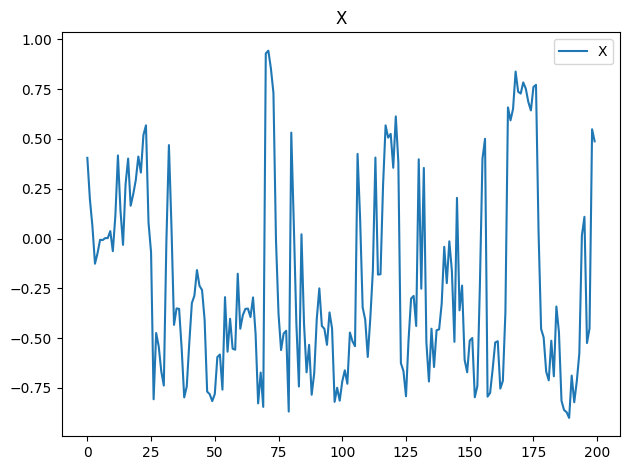

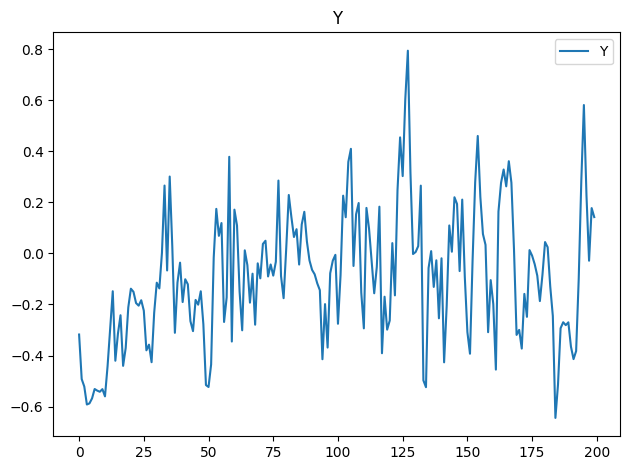

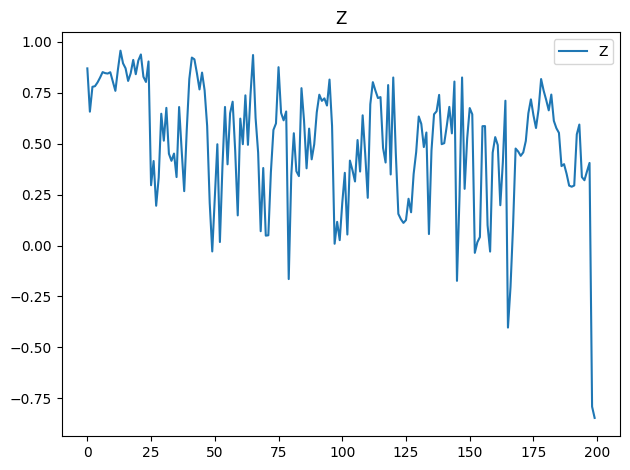

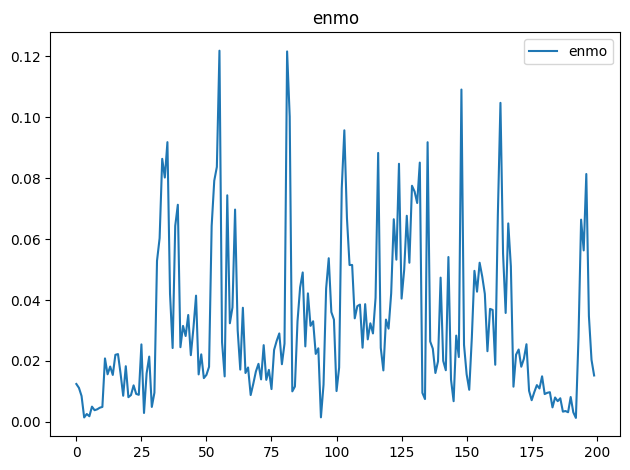

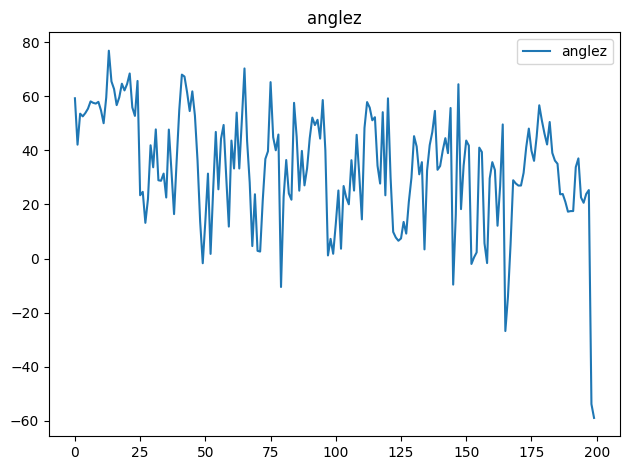

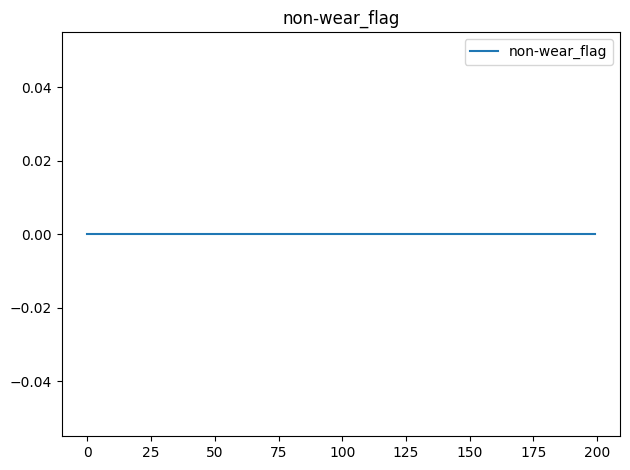

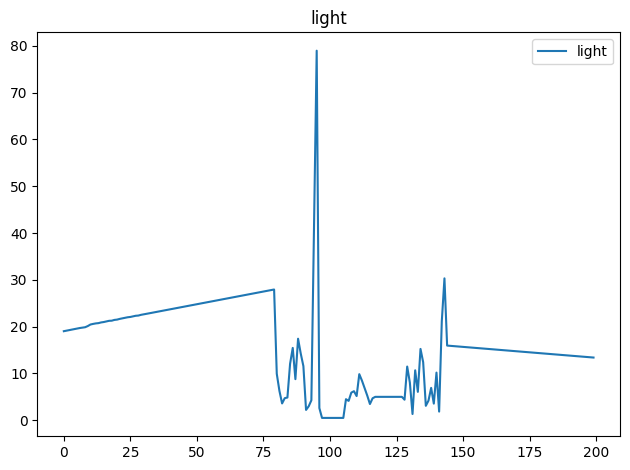

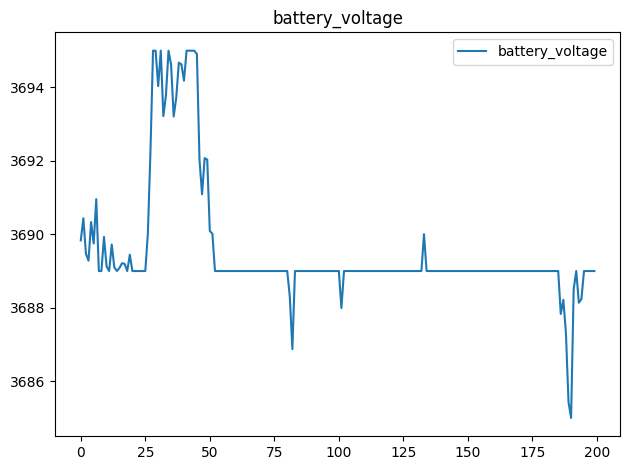

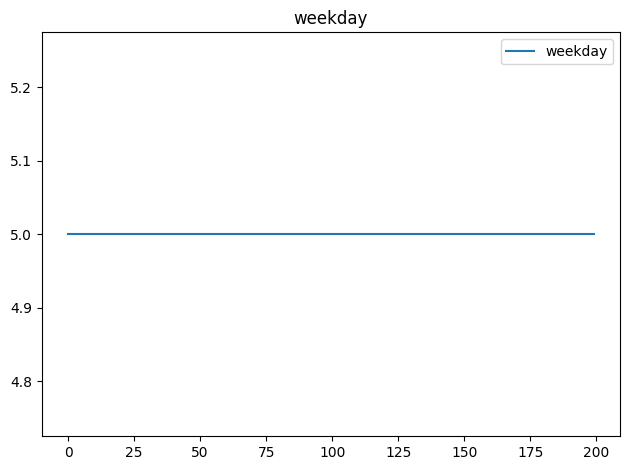

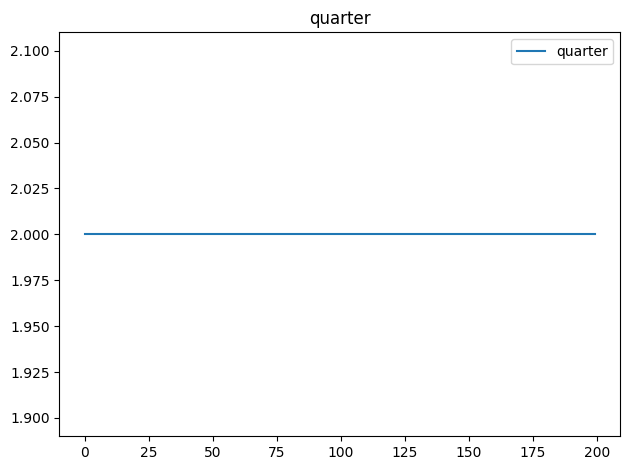

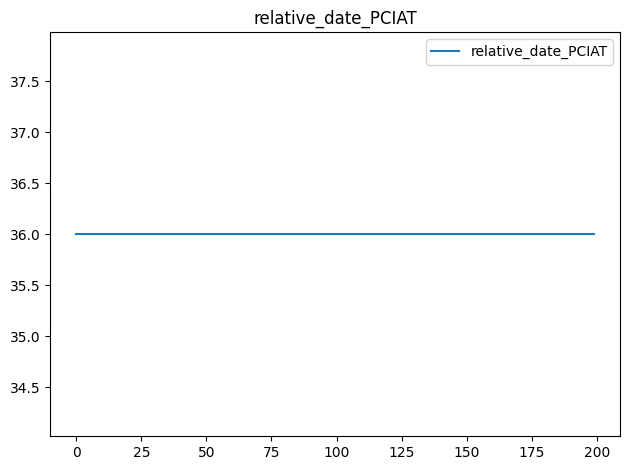

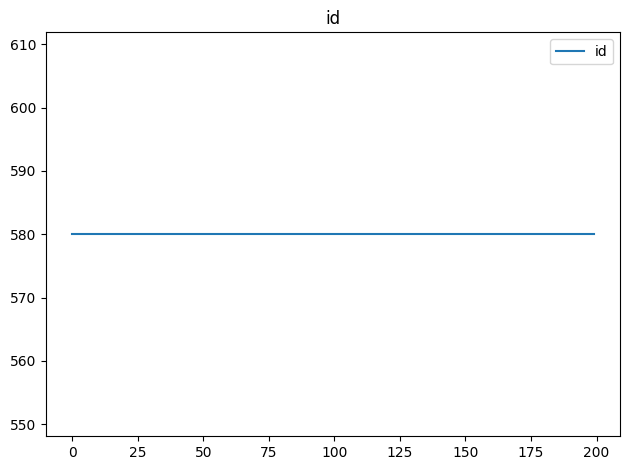

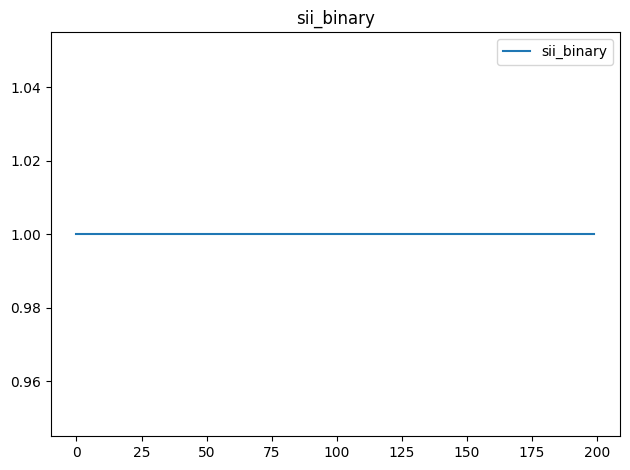

In [39]:
for col in df.columns:
    df[[col]].plot(title=col)
    plt.tight_layout()
    plt.show()

DIAGNOSTIC ANALYSIS FOR SUBJECT 2265


ValueError: The Breusch-Pagan test requires exog to have at least two columns where one is a constant.

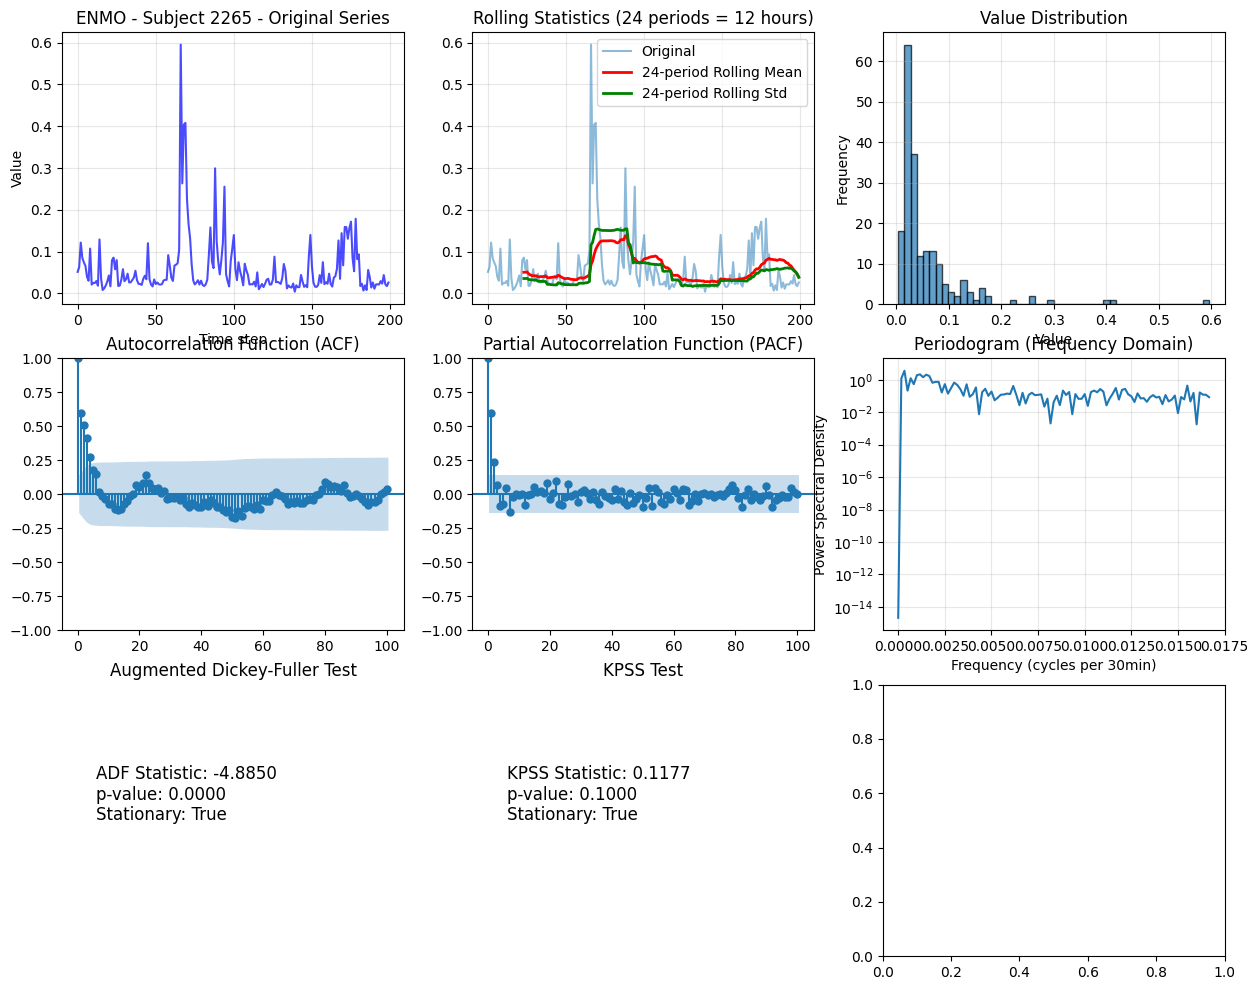

In [40]:
import gzip
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import bartlett, levene, boxcox
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')


def analyze_time_series_properties(ts, title="Time Series"):
    """Comprehensive analysis of a single time series"""
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    
    # 1. Original time series
    axes[0, 0].plot(ts, color='blue', alpha=0.7)
    axes[0, 0].set_title(f'{title} - Original Series')
    axes[0, 0].set_xlabel('Time step')
    axes[0, 0].set_ylabel('Value')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Rolling statistics
    rolling_mean = pd.Series(ts).rolling(window=24).mean()  # 12 hours (24*30min)
    rolling_std = pd.Series(ts).rolling(window=24).std()
    axes[0, 1].plot(ts, alpha=0.5, label='Original')
    axes[0, 1].plot(rolling_mean, 'r-', label='24-period Rolling Mean', linewidth=2)
    axes[0, 1].plot(rolling_std, 'g-', label='24-period Rolling Std', linewidth=2)
    axes[0, 1].set_title('Rolling Statistics (24 periods = 12 hours)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Distribution and heteroscedasticity
    axes[0, 2].hist(ts, bins=50, alpha=0.7, edgecolor='black')
    axes[0, 2].set_title('Value Distribution')
    axes[0, 2].set_xlabel('Value')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. ACF (Autocorrelation Function)
    plot_acf(ts, ax=axes[1, 0], lags=100, alpha=0.05)
    axes[1, 0].set_title('Autocorrelation Function (ACF)')
    
    # 5. PACF (Partial Autocorrelation Function)
    plot_pacf(ts, ax=axes[1, 1], lags=100, alpha=0.05, method='ywm')
    axes[1, 1].set_title('Partial Autocorrelation Function (PACF)')
    
    # 6. Periodogram (frequency domain)
    f, Pxx = signal.periodogram(ts, fs=1/30)  # fs = 1 sample per 30 min = 2 samples per hour
    axes[1, 2].semilogy(f, Pxx)
    axes[1, 2].set_title('Periodogram (Frequency Domain)')
    axes[1, 2].set_xlabel('Frequency (cycles per 30min)')
    axes[1, 2].set_ylabel('Power Spectral Density')
    axes[1, 2].grid(True, alpha=0.3)
    
    # 7. Stationarity tests
    # ADF Test
    adf_result = adfuller(ts, autolag='AIC')
    axes[2, 0].text(0.1, 0.5, f'ADF Statistic: {adf_result[0]:.4f}\np-value: {adf_result[1]:.4f}\nStationary: {adf_result[1] < 0.05}', 
                    fontsize=12, transform=axes[2, 0].transAxes)
    axes[2, 0].set_title('Augmented Dickey-Fuller Test')
    axes[2, 0].axis('off')
    
    # KPSS Test
    kpss_result = kpss(ts, regression='c', nlags='auto')
    axes[2, 1].text(0.1, 0.5, f'KPSS Statistic: {kpss_result[0]:.4f}\np-value: {kpss_result[1]:.4f}\nStationary: {kpss_result[1] > 0.05}', 
                    fontsize=12, transform=axes[2, 1].transAxes)
    axes[2, 1].set_title('KPSS Test')
    axes[2, 1].axis('off')
    
    # 8. Heteroscedasticity test (Breusch-Pagan)
    from statsmodels.stats.diagnostic import het_breuschpagan
    # Create simple trend variable
    x = np.arange(len(ts)).reshape(-1, 1)
    bp_result = het_breuschpagan(ts, x)
    axes[2, 2].text(0.1, 0.5, f'Breusch-Pagan Test\nLM Statistic: {bp_result[0]:.4f}\np-value: {bp_result[1]:.4f}\nHeteroscedastic: {bp_result[1] < 0.05}', 
                    fontsize=12, transform=axes[2, 2].transAxes)
    axes[2, 2].set_title('Heteroscedasticity Test')
    axes[2, 2].axis('off')
    
    plt.suptitle(f'Time Series Diagnostic - {title}', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return {
        'adf_pvalue': adf_result[1],
        'kpss_pvalue': kpss_result[1],
        'bp_pvalue': bp_result[1],
        'is_stationary': adf_result[1] < 0.05 and kpss_result[1] > 0.05
    }

# Analyze one subject's ENMO data
sample_df = CMI_timeseries_dataset[0]
enmo_ts = sample_df['enmo'].values

print("="*80)
print("DIAGNOSTIC ANALYSIS FOR SUBJECT", sample_df['id'].iloc[0])
print("="*80)
diagnostics = analyze_time_series_properties(enmo_ts, title=f"ENMO - Subject {sample_df['id'].iloc[0]}")

# NORMALIZATION